# Activity IV - Fundamental of Cryptography
By: Boonyakorn Tanrattanakorn 6632111021

## Exercise 1 - Cryptanalysis 
Though encryption is primarily designed to preserve confidentiality
and integrity of data, the mechanism itself is vulnerable to brute force (statistical
analysis). In other words, the more we see the encrypted data, the easier we can
hack it. In this exercise, you are asked to crack the following cipher text. Please
provide the decrypted result and explain your strategy in decrypting this text.

<u>**Cipher text**</u>

PRCSOFQX FP QDR AFOPQ CZSPR LA JFPALOQSKR. QDFP FP ZK LIU BROJZK MOLTROE.

In [60]:
### a. Count the frequency of letters. List the top three most frequent characters.
text = "PRCSOFQX FP QDR AFOPQ CZSPR LA JFPALOQSKR. QDFP FP ZK LIU BROJZK MOLTROE."
freq = dict()
for i in text:
    if i in [' ', '.']: continue
    if i not in freq: freq[i] = 1
    else: freq[i] += 1
for (k, v) in sorted(freq.items(), key=lambda item: -item[1])[:3]:
    print(k, v)

P 7
R 6
O 6


### b. 
Knowing that this is English, what are commonly used three-letter words and two-letter words. Does the knowledge give you a hint on cracking the given text?
- three-letter = for, you, the, ...
- two-letter = in, of, at, us, on, we, is, an, ...

We can guess by substituting common short words first.

### c.

Cracking the given text. Measure the time that you have taken to crack this
message.

PRCSOFQX FP QDR AFOPQ CZSPR LA JFPALOQSKR. QDFP FP ZK LIU BROJZK MOLTROE.

security is the first cause of misfortune. this is an old german proverb.

- F=i
- P=s
- R=e
- C=c
- S=u
- Z=a
- Q=t
- D=h
- L=o
- A=f
- O=r
- X=y
- J=m
- K=n
- I=l
- U=d
- M=p
- T=v
- E=b
- B=g

Time used: 17 minutes 51.50 seconds

In [61]:
### d. Create a simple python program for cracking the Caesar cipher text using
#   brute force attack. Explain the design and demonstrate your software.
#   (You may use an English dictionary for validating results.)
"""
Monoalphabetic substitution cipher solver.

  * most-constrained-first search - at each step it expands the word with the
    fewest surviving candidates, so the tree collapses almost immediately;
  * frequency-ranked candidates - common words are tried before obscure ones,
    so you get "OLD GERMAN" rather than the technically-valid "OWD KERMAN".
"""

import os
import re
import sys
import urllib.request

CACHE_DIR = os.path.join(os.path.expanduser("~"), ".cache", "subsolver")
WORDS_URL = "https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt"
FREQ_URL = ("https://raw.githubusercontent.com/hermitdave/FrequencyWords"
            "/master/content/2018/en/en_50k.txt")

# Tried in order. The hunspell/myspell .dic files are what pyenchant itself
# uses, so they are usually present wherever enchant is installed.
CANDIDATE_PATHS = [
    "/usr/share/dict/words",
    "/usr/dict/words",
    "/usr/share/dict/web2",
    "/usr/share/hunspell/en_US.dic",
    "/usr/share/myspell/dicts/en_US.dic",
]


def _download(url, name):
    os.makedirs(CACHE_DIR, exist_ok=True)
    path = os.path.join(CACHE_DIR, name)
    if not os.path.exists(path):
        print(f"Downloading {name} ...")
        urllib.request.urlretrieve(url, path)
    return path


def _read_words(path):
    words = set()
    with open(path, encoding="utf-8", errors="ignore") as fh:
        for line in fh:
            # .dic lines look like "word/AFFIXFLAGS" - keep the stem only
            word = line.split("/")[0].strip().lower()
            if word.isascii() and word.isalpha():
                words.add(word)
    return words


def load_words(path=None):
    """Full word list, from an explicit path, a system dictionary, or the web."""
    for source in ([path] if path else []) + CANDIDATE_PATHS:
        if source and os.path.exists(source):
            words = _read_words(source)
            if len(words) > 5000:
                print(f"Dictionary: {source} ({len(words):,} words)")
                return words
    return _read_words(_download(WORDS_URL, "words_alpha.txt"))


def load_ranks():
    """word -> frequency rank (0 = most common). Missing words rank last."""
    try:
        ranks = {}
        with open(_download(FREQ_URL, "en_50k.txt"), encoding="utf-8",
                  errors="ignore") as fh:
            for i, line in enumerate(fh):        # lines are "word count"
                parts = line.split()
                if parts and parts[0].isalpha():
                    ranks.setdefault(parts[0].lower(), i)
        return ranks
    except Exception as exc:                  # offline: carry on without ranking
        print(f"(no frequency list: {exc})")
        return {}


def pattern(word):
    """Canonical repeated-letter signature: 'proverb' -> (0,1,2,3,4,1,5)."""
    seen = {}
    return tuple(seen.setdefault(ch, len(seen)) for ch in word)


class Solver:
    def __init__(self, words, ranks=None, max_unknown=0, verbose=True, ciphertext=""):
        self.ranks = ranks or {}
        self.index = {}
        for word in words:
            self.index.setdefault((len(word), pattern(word)), []).append(word)
        self.max_unknown = max_unknown   # words allowed to stay unsolved (names, typos)
        self.verbose = verbose
        self.ciphertext = ciphertext
        self.attempts = 0
        self.mapping = {}                # cipher -> plain
        self.reverse = {}                # plain  -> cipher (keeps it a bijection)

    # -- mapping bookkeeping: applied in place, undone on backtrack ----------
    def _apply(self, cipher_word, plain_word):
        """Merge this pairing into the mapping. Returns the list of newly bound
        cipher letters, or None if it clashes with what we already committed."""
        added = []
        for c, p in zip(cipher_word, plain_word):
            known = self.mapping.get(c)
            if known is None:
                if p in self.reverse:            # plain letter already taken
                    break
                self.mapping[c] = p
                self.reverse[p] = c
                added.append(c)
            elif known != p:
                break
        else:
            return added
        self._undo(added)
        return None

    def _undo(self, added):
        for c in added:
            del self.reverse[self.mapping.pop(c)]

    def _fits(self, cipher_word, plain_word):
        """Cheap consistency test with no mutation."""
        for c, p in zip(cipher_word, plain_word):
            known = self.mapping.get(c)
            if known != p and (known is not None or p in self.reverse):
                return False
        return True

    def _candidates(self, cipher_word):
        pool = self.index.get((len(cipher_word), pattern(cipher_word)), ())
        return [w for w in pool if self._fits(cipher_word, w)]

    # -- search -------------------------------------------------------------
    def solve(self, remaining, unknown=0):
        if not remaining:
            return dict(self.mapping)

        # Most-constrained-variable heuristic: expand the hardest word first.
        best = None
        for word in remaining:
            cands = self._candidates(word)
            if not cands and unknown >= self.max_unknown:
                return None                      # dead end, stop early
            if best is None or len(cands) < len(best[1]):
                best = (word, cands)
                if not cands:
                    break
        word, cands = best
        rest = [w for w in remaining if w != word]
        cands.sort(key=lambda w: (self.ranks.get(w, len(self.ranks) + len(w)), w))

        for plain in cands:
            added = self._apply(word, plain)
            if added is None:
                continue
            self.attempts += 1
            if self.verbose and self.attempts % 500 == 0:
                text_preview = decrypt(self.ciphertext, self.mapping)
                print(f"\r[{self.attempts} tries] {text_preview}",
                      end="\033[K", flush=True)
            result = self.solve(rest, unknown)
            if result:
                return result
            self._undo(added)

        # Optionally give up on one word (proper noun, misspelling, ...)
        if unknown < self.max_unknown:
            return self.solve(rest, unknown + 1)
        return None


def decrypt(text, mapping):
    """Apply the mapping, preserving case, spacing and punctuation."""
    out = []
    for ch in text:
        if ch.isalpha():
            plain = mapping.get(ch.upper())
            out.append("?" if plain is None
                       else plain.upper() if ch.isupper() else plain)
        else:
            out.append(ch)
    return "".join(out)


def crack(ciphertext, words=None, ranks=None, max_unknown=0, verbose=True):
    """Return (mapping, attempts). mapping is None if nothing consistent fits.

    Iterative deepening on the number of unsolvable words: a solution where
    every word is real beats one that quietly gives up on a word, so budget 0
    is tried first and only then 1, 2, ... up to max_unknown.
    """
    solver = Solver(words if words is not None else load_words(),
                    ranks if ranks is not None else load_ranks(),
                    verbose=verbose, ciphertext=ciphertext)
    tokens = sorted({w.upper() for w in re.findall(r"[A-Za-z]+", ciphertext)},
                    key=len, reverse=True)

    for budget in range(max_unknown + 1):
        solver.max_unknown = budget
        solver.mapping.clear()
        solver.reverse.clear()
        mapping = solver.solve(tokens)
        if verbose:
            print("\r", end="\033[K")
        if mapping:
            if budget and verbose:
                print(f"(solved with {budget} word(s) left unmatched)")
            return mapping, solver.attempts
    return None, solver.attempts


# --- Run ----------------------------------------------------------------
text = ("PRCSOFQX FP QDR AFOPQ CZSPR LA JFPALOQSKR. "
        "QDFP FP ZK LIU BROJZK MOLTROE.")

mapping, attempts = crack(text, load_words(), load_ranks(),
                          max_unknown=1)

print(f"Candidate words tried: {attempts}")
if not mapping:
    print("No solution. Try a bigger dictionary or max_unknown=2.")
else:
    print("Key (cipher->plain):",
          " ".join(f"{c}->{p}" for c, p in sorted(mapping.items())))
    print("Ciphertext:", text)
    print("Plaintext :", decrypt(text, mapping))

Candidate words tried: 48
Key (cipher->plain): A->f B->g C->c D->h E->b F->i I->l J->m K->n L->o M->p O->r P->s Q->t R->e S->u T->v U->d X->y Z->a
Ciphertext: PRCSOFQX FP QDR AFOPQ CZSPR LA JFPALOQSKR. QDFP FP ZK LIU BROJZK MOLTROE.
Plaintext : SECURITY IS THE FIRST CAUSE OF MISFORTUNE. THIS IS AN OLD GERMAN PROVERB.


## Exercise 2 - Cryptanalysis on Symmetric Encryption

Vigenère is a complex version of the Caesar cipher. It is a polyalphabetic substitution.

- a. Please review Kasiski examination Explain how it can be used to attack Vigenère.

First, we need to deduce the keyword length. Look for repeated strings that is three or more characters long. Then, the distances between strings consecutive occurences are likely to be multiples of the keyword length. After that, we can line up the ciphertext into n columns and use frequency analysis to crack the crypt.

[Kasiski examination](https://en.wikipedia.org/wiki/Kasiski_examination)

## Exercise 3 - Mode in Block Cipher (ECB Weakness)

Block Cipher is designed to have more randomness in a block. However, an
individual block still utilizes the same key. This exercise demonstrates the
weakness of **Electronic Code Book (ECB)** mode, which does not include any
initial vector, chaining, or feedback.

Loaded (658×761, 1-bit PBM)


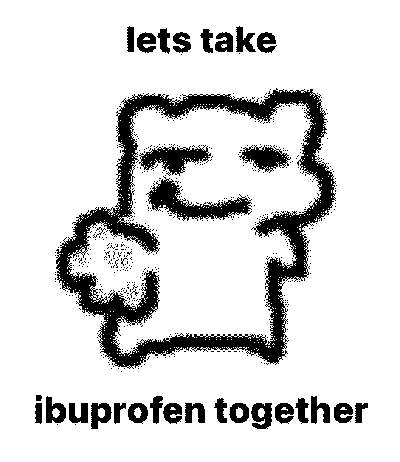

In [62]:
from PIL import Image
import subprocess, os

WORK = os.path.join(os.getcwd(), "tmp")
os.makedirs(WORK, exist_ok=True)

# Use a real photo with large uniform regions (background) so ECB's
# pattern-leakage is easy to see
src_path = os.path.join(os.getcwd(), "ibuprofen.jpg")
img = Image.open(src_path).convert("RGB")

# Convert to 1-bit PBM (P4 binary)
org = img.convert("1")
org_path = os.path.join(WORK, "org.pbm")
org.save(org_path)
print(f"Loaded ({org.size[0]}×{org.size[1]}, 1-bit PBM)")
display(org.resize((400, int(400 * org.size[1] / org.size[0]))))


In [63]:
def split_pbm(path):
    """Return (header_bytes, body_bytes) for a P4 PBM file."""
    with open(path, "rb") as f:
        data = f.read()
    idx = 0
    nl = data.index(b"\n", idx); idx = nl + 1          # skip "P4"
    while data[idx : idx + 1] == b"#":                  # skip comments
        nl = data.index(b"\n", idx); idx = nl + 1
    nl = data.index(b"\n", idx); idx = nl + 1           # skip "W H"
    return data[:idx], data[idx:]

header, body = split_pbm(org_path)
print(f"Header ({len(header)} B): {header}")
print(f"Body : {len(body):,} bytes  (divisible by 16? {len(body) % 16 == 0})")

# Save body only (header stripped)
body_path = os.path.join(WORK, "org.x")
with open(body_path, "wb") as f:
    f.write(body)
    # Pad to AES block size (16 B) if needed
    pad = (16 - len(body) % 16) % 16
    if pad:
        f.write(b"\x00" * pad)
        print(f"  + padded {pad} bytes")

# AES-256 key (64 hex = 32 bytes) and IV (32 hex = 16 bytes)
KEY = "0123456789ABCDEF0123456789ABCDEF0123456789ABCDEF0123456789ABCDEF"
IV  = "0123456789ABCDEF0123456789ABCDEF"

modes = {
    "ecb": ["-aes-256-ecb"],
    "cbc": ["-aes-256-cbc", "-iv", IV],
    "ofb": ["-aes-256-ofb", "-iv", IV],
    "cfb": ["-aes-256-cfb", "-iv", IV],
}

for name, flags in modes.items():
    enc_path = os.path.join(WORK, f"enc_{name}.x")
    pbm_path = os.path.join(WORK, f"enc_{name}.pbm")

    # Encrypt
    subprocess.run(
        ["openssl", "enc"] + flags +
        ["-in", body_path, "-out", enc_path, "-nosalt", "-nopad", "-K", KEY],
        check=True,
    )

    # Reattach PBM header
    with open(enc_path, "rb") as f:
        enc_data = f.read()
    with open(pbm_path, "wb") as f:
        f.write(header)
        f.write(enc_data[: len(body)])  # trim any padding

    print(f"  {name.upper():4s} → {pbm_path}")

print("Done!")


Header (11 B): b'P4\n658 761\n'
Body : 63,163 bytes  (divisible by 16? False)
  + padded 5 bytes
  ECB  → c:\Users\Korn-PC\UniversityCode\Computer Security\tmp\enc_ecb.pbm
  CBC  → c:\Users\Korn-PC\UniversityCode\Computer Security\tmp\enc_cbc.pbm
  OFB  → c:\Users\Korn-PC\UniversityCode\Computer Security\tmp\enc_ofb.pbm
  CFB  → c:\Users\Korn-PC\UniversityCode\Computer Security\tmp\enc_cfb.pbm
Done!


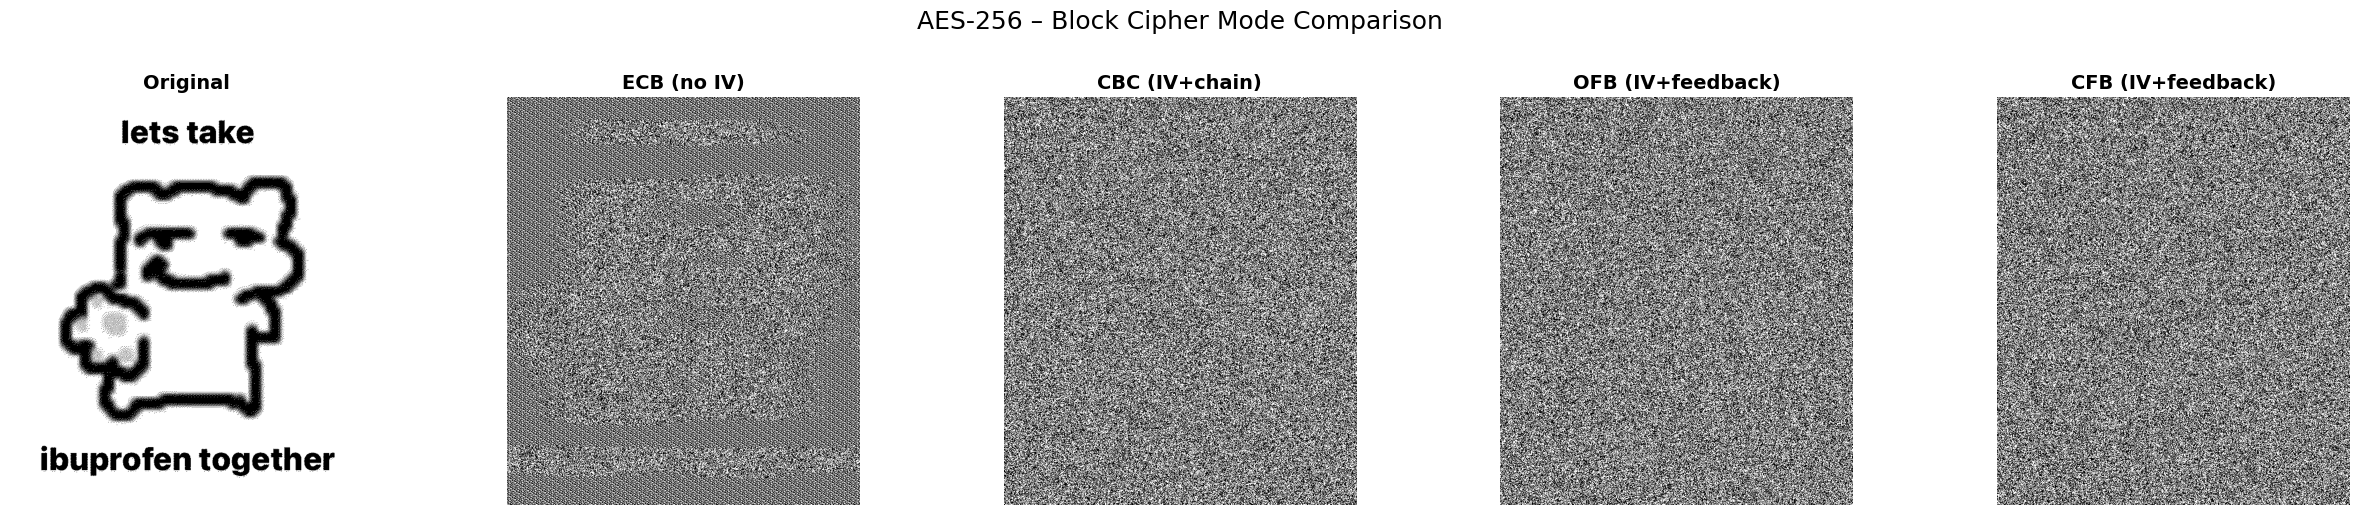

In [64]:
import matplotlib.pyplot as plt

labels = ["Original", "ECB (no IV)", "CBC (IV+chain)", "OFB (IV+feedback)", "CFB (IV+feedback)"]
files  = ["org.pbm", "enc_ecb.pbm", "enc_cbc.pbm", "enc_ofb.pbm", "enc_cfb.pbm"]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, label, fname in zip(axes, labels, files):
    im = Image.open(os.path.join(WORK, fname))
    ax.imshow(im, cmap="gray")
    ax.set_title(label, fontsize=14, fontweight="bold")
    ax.axis("off")

fig.suptitle("AES-256 – Block Cipher Mode Comparison", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(WORK, "block_cipher_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

### f. Analysis

| Mode | IV / Chaining | Observation |
|------|---------------|-------------|
| **ECB** | None | The outline of the original image is **clearly visible** in the ciphertext. Identical 16-byte plaintext blocks always produce the same ciphertext block, so large uniform areas (all-black, all-white) map to repeating ciphertext patterns. |
| **CBC** | IV + chaining | The encrypted image looks like **pure noise**. Each block is XORed with the previous ciphertext block before encryption, so even identical plaintext blocks produce different ciphertext. |
| **OFB** | IV + feedback | Also looks like **pure noise**. The IV generates a key-stream that is XORed with plaintext, so identical blocks encrypt differently. |
| **CFB** | IV + feedback | Same result — **random noise**. Similar feedback mechanism to OFB. |

**Conclusion:** ECB mode is insecure for structured data (images, formatted
text, databases) because it preserves patterns. Any mode that incorporates
an IV and chaining/feedback (CBC, OFB, CFB, CTR, GCM…) breaks this pattern
repetition and produces ciphertext that is indistinguishable from random.


## Exercise 4 - Encryption Protocol & Digital Signature

### a. Performance Measurement
We benchmark **SHA-1** (hash), **RC4** (stream cipher), **Blowfish** (block
cipher) and **DSA** (digital signature) using `openssl speed`.

In [65]:
import subprocess, time

# Use openssl speed for standardised throughput numbers
# RC4 and Blowfish live in OpenSSL 3.x's "legacy" provider, which is not
# loaded by default, so it must be requested explicitly alongside "default".
algorithms = ["sha1", "rc4", "bf-cbc"]

print("=" * 70)
print("OpenSSL Throughput Benchmarks  (higher = faster)")
print("=" * 70)

for alg in algorithms:
    print(f"\n{'─'*70}")
    print(f"  Algorithm: {alg.upper()}")
    print(f"{'─'*70}")
    result = subprocess.run(
        ["openssl", "speed", "-provider", "legacy", "-provider", "default",
         "-seconds", "3", "-bytes", "8192", alg],
        capture_output=True, text=True,
    )
    # Print last few meaningful lines (the results table)
    for line in (result.stdout + result.stderr).splitlines():
        if line.strip():
            print(f"  {line}")

# DSA benchmark
print(f"\n{'─'*70}")
print(f"  Algorithm: DSA (sign + verify)")
print(f"{'─'*70}")
result = subprocess.run(
    ["openssl", "speed", "-seconds", "3", "dsa2048"],
    capture_output=True, text=True,
)
for line in (result.stdout + result.stderr).splitlines():
    if line.strip():
        print(f"  {line}")

OpenSSL Throughput Benchmarks  (higher = faster)

──────────────────────────────────────────────────────────────────────
  Algorithm: SHA1
──────────────────────────────────────────────────────────────────────
  version: 3.6.2
  built on: Tue Apr  7 18:45:06 2026 UTC
  options: bn(64,64)
  compiler: cl.exe  /Zi /Fdossl_static.pdb /Gs0 /GF /Gy /MD /W3 /wd4090 /nologo /O2 -DL_ENDIAN -DOPENSSL_PIC -D"OPENSSL_BUILDING_OPENSSL" -D"OPENSSL_SYS_WIN32" -D"WIN32_LEAN_AND_MEAN" -D"UNICODE" -D"_UNICODE" -D"_CRT_SECURE_NO_DEPRECATE" -D"_WINSOCK_DEPRECATED_NO_WARNINGS" -D"NDEBUG"
  CPUINFO: OPENSSL_ia32cap=0xffdaf38bffcbffff:0x184007a4239c27a9:0x00400810bc18c410:0x0000000000000000:0x0000000000000000
  The 'numbers' are in 1000s of bytes per second processed.
  type           8192 bytes
  sha1           6739882.91k
  Doing sha1 ops for 3s on 8192 size blocks: 797029 sha1 ops in 0.97s

──────────────────────────────────────────────────────────────────────
  Algorithm: RC4
────────────────────────────

In [66]:
import time, os

test_file = os.path.join(WORK, "testfile_10mb.bin")
with open(test_file, "wb") as f:
    f.write(os.urandom(10 * 1024 * 1024))  # 10 MB random data

KEY32 = "0123456789ABCDEF0123456789ABCDEF0123456789ABCDEF0123456789ABCDEF"
KEY16 = KEY32[:32]
IV    = "0123456789ABCDEF0123456789ABCDEF"

# RC4 and Blowfish live in OpenSSL 3.x's "legacy" provider
LEGACY = ["-provider", "legacy", "-provider", "default"]

results = {}

# SHA-1 (hash)
t0 = time.perf_counter()
subprocess.run(["openssl", "dgst", "-sha1", test_file],
               capture_output=True, check=True)
results["SHA-1"] = time.perf_counter() - t0

# RC4 (stream cipher)
t0 = time.perf_counter()
subprocess.run(["openssl", "enc", "-rc4"] + LEGACY + ["-in", test_file,
                "-out", os.path.join(WORK, "enc_rc4.bin"),
                "-K", KEY16, "-nosalt"],
               capture_output=True, check=True)
results["RC4"] = time.perf_counter() - t0

# Blowfish-CBC (block cipher)
t0 = time.perf_counter()
subprocess.run(["openssl", "enc", "-bf-cbc"] + LEGACY + ["-in", test_file,
                "-out", os.path.join(WORK, "enc_bf.bin"),
                "-K", KEY16, "-iv", IV[:16], "-nosalt"],
               capture_output=True, check=True)
results["Blowfish"] = time.perf_counter() - t0

# DSA-2048 (generate key + sign)
dsa_key = os.path.join(WORK, "dsa_key.pem")
subprocess.run(["openssl", "dsaparam", "-genkey", "-out", dsa_key, "2048"],
               capture_output=True, check=True)
t0 = time.perf_counter()
subprocess.run(["openssl", "dgst", "-sha1", "-sign", dsa_key,
                "-out", os.path.join(WORK, "sig.bin"), test_file],
               capture_output=True, check=True)
results["DSA-2048 sign"] = time.perf_counter() - t0

print(f"\nManual Timing – Encrypting / Hashing / Signing a 10 MB file")
print(f"{'Algorithm':<20s} {'Time (s)':>10s} {'Throughput':>14s}")
print("─" * 46)
for alg, t in results.items():
    tp = f"{10 / t:.1f} MB/s" if t > 0 else "N/A"
    print(f"{alg:<20s} {t:>10.4f} {tp:>14s}")


Manual Timing – Encrypting / Hashing / Signing a 10 MB file
Algorithm              Time (s)     Throughput
──────────────────────────────────────────────
SHA-1                    0.0295     338.7 MB/s
RC4                      0.0523     191.3 MB/s
Blowfish                 0.0894     111.8 MB/s
DSA-2048 sign            0.0261     383.8 MB/s


### b. Performance & Security Comparison

| Method | Type | Speed | Security | Key Size |
|--------|------|-------|----------|----------|
| **SHA-1** | Hash function | Very fast | Provides **integrity** only (no confidentiality). Vulnerable to collision attacks, so it's deprecated for signatures. | N/A (no key) |
| **RC4** | Stream cipher | Very fast | Provides **confidentiality**, but has known biases in its key-stream and is considered **broken** — it's been prohibited in TLS since 2015. | 40–2048 bits |
| **Blowfish** | Block cipher | Fast | Provides **confidentiality**, but its 64-bit block size makes it vulnerable to birthday attacks on large data. Superseded by AES. | 32–448 bits |
| **DSA-2048** | Asymmetric signature | Slow | Provides **authentication, integrity, and non-repudiation**. It's computationally expensive, but only operates on a small hash rather than the full message. | 2048-bit key |

**Key take-away:** symmetric ciphers like RC4 and Blowfish are orders of magnitude faster than asymmetric operations like DSA, but they can't provide non-repudiation or solve the key-distribution problem on their own.

### c. Digital Signature Mechanism

A digital signature combines hashing and asymmetric cryptography to get the best of both worlds. Rather than encrypting the whole message with a slow asymmetric algorithm, the sender first hashes the message down to a small, fixed-size digest, and only that digest gets signed.

**Signing (sender):**
1. Compute `H(M)`, a fixed-size hash of the message (fast, e.g. SHA-256).
2. Encrypt `H(M)` with the sender's private key to produce the signature. This step is slow, but it only operates on the small hash, not the entire message.

**Verification (receiver):**
1. Compute `H(M)` from the received message.
2. Decrypt the signature with the sender's public key to recover `H'`.
3. If `H(M)` equals `H'`, the signature is valid.

**How it combines strengths and compensates weaknesses:**

| Component | Strength used | Weakness avoided |
|-----------|---------------|------------------|
| Hash (SHA) | Fast on arbitrarily large data, reducing the message to a fixed size | Cannot provide authentication alone, since it uses no key |
| Asymmetric (DSA/RSA) | Provides authentication, integrity, and non-repudiation | Far too slow to encrypt the entire message |
| Combined | The hash makes the message small enough to sign quickly, and the asymmetric step signs only that hash | Neither weakness matters on its own — speed comes from hashing, trust comes from asymmetric signing |

This is why digital signatures underpin TLS certificates, code signing, and blockchain transactions.
